# Introdução

Nesta seção final da exploração, vamos analisar os resultados da alteração feita ao introduzir a transferência de renda da população trabalhadora para os donos das empresas no modelo como proxy de um mercado de apostas. 

Para fazer isto, vamos:
1. Entender como foi feita a transferência de renda.
2. Procurar explicar como essa transferência pode impactar o crescimento econômico.
3. Avaliar se esta hipótese é coerente com o que foi verificado durante as simulações. 

## Transferências do mercado de apostas

O mercado de apostas foi introduzido como um mecanismo estilizado de transferência de renda entre famílias. Nesta versão, não existem casas de apostas, produção de serviços de apostas, probabilidades de vitória ou tributação específica, o mecanismo representa uma transferência recorrente de trabalhadores para proprietários de empresas. A implementação detalhada do mecanismo aparece na **Parte 2, Seção 2.37 — Transferências do mercado de apostas**.

### Participantes e parâmetros

Sejam:

- $g \in [0,1]$ a parcela da renda destinada às apostas, armazenada em `gambling_income_share`;
- $G_A$ o conjunto fixo de trabalhadores ativos selecionados;
- $G_N$ o conjunto fixo de trabalhadores inativos selecionados;
- $R$ o conjunto de proprietários de empresas que recebem os recursos;
- $Y^{A,0}_{h,t}$ e $Y^{N,0}_{h,t}$ as rendas dos trabalhadores antes das apostas;
- $Y^{O,0}_{i,t}$ a renda dos proprietários antes dos recebimentos.

Na configuração experimental, aproximadamente 10% dos trabalhadores são selecionados como apostadores e 10% dos proprietários como destinatários. Os mesmos agentes permanecem nessas funções durante toda a simulação. No cenário com apostas, utiliza-se $g=0{,}02$; no cenário de referência, $g=0$.

### Valor transferido pelos trabalhadores

Cada trabalhador selecionado transfere uma proporção fixa de sua renda disponível não negativa:

$$
B^A_{h,t}=\mathbf{1}(h\in G_A)\,g\max(0,Y^{A,0}_{h,t}),
$$

$$
B^N_{h,t}=\mathbf{1}(h\in G_N)\,g\max(0,Y^{N,0}_{h,t}).
$$

O operador $\max(0,Y)$ impede que agentes com renda negativa realizem apostas. Trabalhadores não selecionados transferem zero. O desconto sobre as rendas esperadas é apresentado na **Parte 2, Seção 2.18 — Orçamento dos trabalhadores ativos** e na **Seção 2.19 — Orçamento das pessoas inativas**.

O volume total de apostas no período é:

$$
B_t=\sum_h B^A_{h,t}+\sum_h B^N_{h,t}.
$$

Esse valor é armazenado pelo modelo em `gambling_volume`.

### Distribuição aos proprietários

O volume arrecadado é dividido igualmente entre os proprietários selecionados:

$$
R_{i,t}=
\begin{cases}
\dfrac{B_t}{|R|}, & i\in R,\\[6pt]
0, & i\notin R.
\end{cases}
$$

A inclusão dessas receitas no orçamento esperado dos beneficiários é detalhada na **Parte 2, Seção 2.20 — Orçamento dos proprietários das empresas**. As rendas depois da transferência são:

$$
Y^A_{h,t}=Y^{A,0}_{h,t}-B^A_{h,t},
$$

$$
Y^N_{h,t}=Y^{N,0}_{h,t}-B^N_{h,t},
$$

$$
Y^O_{i,t}=Y^{O,0}_{i,t}+R_{i,t}.
$$

O proprietário do banco não participa do mecanismo, nem como apostador nem como destinatário. Seu orçamento permanece conforme a **Parte 2, Seção 2.21 — Orçamento do proprietário do banco**.

### Conservação da renda

A transferência é de soma zero, pois todo o valor retirado dos trabalhadores é entregue aos proprietários:

$$
\sum_h B^A_{h,t}+\sum_h B^N_{h,t}=\sum_i R_{i,t}.
$$

Consequentemente, a renda agregada das famílias é preservada:

$$
\sum_h Y^A_{h,t}+\sum_h Y^N_{h,t}+\sum_i Y^O_{i,t}
=\sum_h Y^{A,0}_{h,t}+\sum_h Y^{N,0}_{h,t}+\sum_i Y^{O,0}_{i,t}.
$$

A demonstração operacional dessa conservação encontra-se na **Parte 2, Seção 2.37**. A transferência não é tributada, não representa produção e não é adicionada diretamente ao PIB.

### Incorporação no ciclo do modelo

O mecanismo aparece em dois momentos distintos:

1. **Formação dos orçamentos:** a transferência esperada é descontada da renda dos apostadores e adicionada à renda dos proprietários antes do cálculo das demandas desejadas, conforme as **Seções 2.18 a 2.20 da Parte 2**.

2. **Atualização contábil:** depois do cálculo das rendas realizadas nas **Seções 2.33 a 2.35 da Parte 2**, a transferência efetiva é executada pela rotina descrita na **Seção 2.37**, antes da atualização dos depósitos apresentada nas **Seções 2.38 a 2.40**.

A renda esperada após as apostas, $\widetilde{Y}^{e}_{h,t}$, determina as demandas desejadas:

$$
C^d_{h,t}=\frac{\psi\widetilde{Y}^{e}_{h,t}}{1+\tau_{VAT}},
\qquad
I^d_{h,t}=\frac{\psi_H\widetilde{Y}^{e}_{h,t}}{1+\tau_{CF}}.
$$

Assim, as apostas competem com consumo, investimento residencial e poupança no orçamento dos apostadores. Para os proprietários beneficiados, os recebimentos ampliam essas mesmas possibilidades.

```text
renda esperada
    → transferência esperada
    → consumo e investimento desejados
    → mercados
    → renda realizada
    → transferência efetiva
    → depósitos e poupança
```

Como todos os tipos de família usam as mesmas propensões $\psi$ e $\psi_H$, o efeito imediato sobre a demanda agregada tende a ser pequeno. O efeito de primeira ordem é distributivo: apostadores perdem renda e depósitos, enquanto proprietários selecionados os acumulam. Efeitos sobre produção e PIB surgem apenas indiretamente, por meio das restrições, heterogeneidades e interações posteriores do modelo.

## Desenho da análise

A unidade de comparação é o par formado pelo mesmo `run`, pela mesma `simulation_seed` e pelo mesmo período. Para qualquer variável $X$, calculamos:

$$
\Delta X_{r,t}=X^{apostas}_{r,t}-X^{baseline}_{r,t}.
$$

Um valor positivo indica que a variável foi maior no cenário com apostas. A análise começa pelas validações do experimento, mede o efeito sobre o PIB, reconcilia seus componentes e só depois acompanha a renda pelas famílias e empresas.

In [1]:
using CSV
using DataFrames
using Statistics
using Plots
using Distributions: TDist
using Markdown
using Printf

default(size = (900, 450), linewidth = 2, markerstrokewidth = 0)

study_dir = isfile(joinpath(pwd(), "paired-period-trace.csv")) ?
    pwd() : joinpath(pwd(), "dba-studies", "gambling-market")
trace_path = joinpath(study_dir, "paired-period-trace.csv")
@assert isfile(trace_path) "Arquivo não encontrado: $trace_path"

trace = CSV.read(trace_path, DataFrame)
sort!(trace, [:run, :scenario, :period])


Row,run,scenario,simulation_seed,period,gambling_income_share,active_gamblers,inactive_gamblers,recipient_owners,active_worker_stakes,inactive_worker_stakes,owner_receipts,transfer_residual,gambling_volume,gambler_income_pre,gambler_income_post,other_worker_income,recipient_owner_income_pre,recipient_owner_income_post,other_owner_income,gambler_consumption_desired,gambler_consumption_realized,other_worker_consumption_desired,other_worker_consumption_realized,recipient_owner_consumption_desired,recipient_owner_consumption_realized,other_owner_consumption_desired,other_owner_consumption_realized,gambler_housing_desired,gambler_housing_realized,other_worker_housing_desired,other_worker_housing_realized,recipient_owner_housing_desired,recipient_owner_housing_realized,other_owner_housing_desired,other_owner_housing_realized,gambler_deposits,other_worker_deposits,recipient_owner_deposits,other_owner_deposits,household_consumption_desired,household_consumption_realized,household_housing_desired,household_housing_realized,firm_output_desired,firm_output_realized,firm_sales,firm_revenue,firm_profit,firm_employment_desired,firm_employment_realized,firm_investment_desired,firm_investment_realized,firm_credit_desired,firm_credit_realized,firm_capital_stock,firm_material_stock,firm_finished_goods_stock,firm_deposits,firm_loans,nominal_gdp,real_gdp,nominal_gva,real_gva,nominal_household_consumption,real_household_consumption,nominal_government_consumption,real_government_consumption,nominal_capitalformation,real_capitalformation,nominal_exports,real_exports,nominal_imports,real_imports,nominal_gdp_expenditure_residual,real_gdp_expenditure_residual
,Int64,String15,Int64,Int64,Float64,Int64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Int64,Int64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64,Float64
1,1,baseline,10001,0,0.0,425,400,62,0.0,0.0,0.0,0.0,0.0,3369.09,3369.09,30242.7,915.306,915.306,6313.51,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,16630.7,1.49286e5,4518.18,31165.1,0.0,0.0,0.0,0.0,0.0,1.34636e5,0.0,0.0,10175.1,0,3866,0.0,0.0,0.0,0.0,750826.0,80090.1,0.0,54049.0,236919.0,72422.0,72422.0,64900.9,64900.9,40512.9,40512.9,14866.9,14866.9,15944.2,15944.2,34195.6,34195.6,33097.6,33097.6,5.09317e-11,5.09317e-11
2,1,baseline,10001,1,0.0,425,400,62,0.0,0.0,0.0,0.0,0.0,3395.38,3395.38,30476.0,920.903,920.903,6346.77,2679.12,2678.63,24047.0,24044.9,727.993,727.859,5021.48,5020.99,222.436,222.386,1996.52,1996.42,60.4421,59.8483,416.912,416.912,16734.1,1.5021e5,4545.18,31341.0,35414.8,35411.5,2940.34,2939.59,1.35285e5,1.35285e5,1.35021e5,1.35447e5,10193.3,3867,3867,12832.5,12832.5,4124.96,4124.96,750826.0,80090.1,263.597,46558.5,229198.0,72997.8,72767.9,65419.7,65213.7,40824.8,40696.2,14753.0,14706.5,16334.7,16283.2,34729.6,34620.2,33644.2,33538.2,3.92902e-10,3.27418e-10
3,1,baseline,10001,2,0.0,425,400,62,0.0,0.0,0.0,0.0,0.0,3417.95,3417.95,30676.1,944.944,944.944,6532.95,2696.92,2696.92,24204.9,24204.6,733.053,732.942,5052.13,5051.23,223.914,223.914,2009.63,2009.63,60.8623,60.8612,419.457,419.299,16836.9,1.51134e5,4589.16,31665.0,35654.4,35635.5,2960.24,2960.07,1.35951e5,1.35951e5,136076.0,136798.0,10542.5,3868,3868,12893.1,12893.1,5800.89,5800.89,750826.0,80090.1,138.327,41578.6,223539.0,73468.9,73081.2,65843.2,65495.7,41083.1,40866.3,15160.6,15080.5,16054.9,15970.2,35200.7,35015.0,34030.4,33850.8,-3.20142e-10,-3.34694e-10
4,1,baseline,10001,3,0.0,425,400,62,0.0,0.0,0.0,0.0,0.0,3435.98,3435.98,30828.4,965.434,965.434,6720.29,2711.15,2709.87,24325.1,24307.1,748.701,747.866,5176.21,5171.86,225.096,

In [2]:
gambling_trace = filter(:scenario => ==("gambling"), trace)
baseline_trace = filter(:scenario => ==("baseline"), trace)

experiment_summary = DataFrame(
    medida = [
        "Execuções pareadas",
        "Cenários",
        "Períodos, incluindo t = 0",
        "Linhas do rastreamento",
        "Parcela da renda apostada",
    ],
    valor = [
        string(length(unique(trace.run))),
        join(sort(unique(trace.scenario)), " e "),
        string(length(unique(trace.period))),
        string(nrow(trace)),
        @sprintf("%.2f%%", 100 * only(unique(gambling_trace.gambling_income_share))),
    ],
)

experiment_summary

Row,medida,valor
,String,String
1,Execuções pareadas,20
2,Cenários,baseline e gambling
3,"Períodos, incluindo t = 0",17
4,Linhas do rastreamento,680
5,Parcela da renda apostada,2.00%


## 1. Validação do experimento

Antes de interpretar qualquer diferença, verificamos que os pares usam as mesmas sementes e os mesmos participantes, que o estado inicial coincide, que o baseline não possui apostas, que toda aposta chega aos proprietários e que as identidades contábeis do PIB fecham.

In [3]:
pair_keys = [:run, :simulation_seed, :period]
participant_columns = [:active_gamblers, :inactive_gamblers, :recipient_owners]
sort!(baseline_trace, pair_keys)
sort!(gambling_trace, pair_keys)

same_pairing = nrow(baseline_trace) == nrow(gambling_trace) &&
    all(baseline_trace[!, column] == gambling_trace[!, column] for column in vcat(pair_keys, participant_columns))

initial_columns = [
    :real_gdp, :nominal_gdp, :gambler_deposits, :other_worker_deposits,
    :recipient_owner_deposits, :other_owner_deposits, :firm_capital_stock,
    :firm_material_stock, :firm_finished_goods_stock, :firm_deposits, :firm_loans,
]
baseline_initial = baseline_trace.period .== 0
gambling_initial = gambling_trace.period .== 0
max_initial_difference = maximum(
    maximum(abs.(baseline_trace[baseline_initial, column] .- gambling_trace[gambling_initial, column]))
    for column in initial_columns
)

validation = DataFrame(
    verificacao = [
        "680 observações esperadas",
        "Mesmas sementes e participantes em cada par",
        "Mesmo estado inicial",
        "Baseline sem apostas",
        "Apostas iguais aos recebimentos",
        "Volume igual à soma das apostas",
        "Identidade do PIB real",
        "Identidade do PIB nominal",
    ],
    erro_maximo = [
        abs(nrow(trace) - 20 * 2 * 17),
        Float64(!same_pairing),
        max_initial_difference,
        maximum(abs.(baseline_trace.gambling_volume)),
        maximum(abs.(trace.transfer_residual)),
        maximum(abs.(trace.gambling_volume .- trace.active_worker_stakes .- trace.inactive_worker_stakes)),
        maximum(abs.(trace.real_gdp_expenditure_residual)),
        maximum(abs.(trace.nominal_gdp_expenditure_residual)),
    ],
    tolerancia = [0.0, 0.0, 1e-10, 0.0, 1e-10, 1e-10, 1e-6, 1e-6],
)
validation.passou = validation.erro_maximo .<= validation.tolerancia
@assert all(validation.passou)
validation

Row,verificacao,erro_maximo,tolerancia,passou
,String,Float64,Float64,Bool
1,680 observações esperadas,0.0,0.0,true
2,Mesmas sementes e participantes em cada par,0.0,0.0,true
3,Mesmo estado inicial,0.0,1.0e-10,true
4,Baseline sem apostas,0.0,0.0,true
5,Apostas iguais aos recebimentos,2.84217e-14,1.0e-10,true
6,Volume igual à soma das apostas,7.10543e-15,1.0e-10,true
7,Identidade do PIB real,1.06957e-9,1.0e-6,true
8,Identidade do PIB nominal,1.13505e-9,1.0e-6,true


## 2. Construção das diferenças pareadas

As linhas dos dois cenários já estão na mesma ordem. A tabela `paired` guarda os valores de cada cenário e a diferença `gambling - baseline` para todas as variáveis usadas nas seções seguintes.

In [4]:
analysis_columns = [
    :real_gdp, :nominal_gdp,
    :real_household_consumption, :real_government_consumption,
    :real_capitalformation, :real_exports, :real_imports,
    :active_worker_stakes, :inactive_worker_stakes, :owner_receipts, :gambling_volume,
    :gambler_income_pre, :gambler_income_post, :other_worker_income,
    :recipient_owner_income_pre, :recipient_owner_income_post, :other_owner_income,
    :gambler_consumption_desired, :gambler_consumption_realized,
    :other_worker_consumption_desired, :other_worker_consumption_realized,
    :recipient_owner_consumption_desired, :recipient_owner_consumption_realized,
    :other_owner_consumption_desired, :other_owner_consumption_realized,
    :gambler_housing_desired, :gambler_housing_realized,
    :other_worker_housing_desired, :other_worker_housing_realized,
    :recipient_owner_housing_desired, :recipient_owner_housing_realized,
    :other_owner_housing_desired, :other_owner_housing_realized,
    :gambler_deposits, :other_worker_deposits, :recipient_owner_deposits, :other_owner_deposits,
    :household_consumption_desired, :household_consumption_realized,
    :household_housing_desired, :household_housing_realized,
    :firm_output_desired, :firm_output_realized, :firm_sales, :firm_revenue, :firm_profit,
    :firm_employment_desired, :firm_employment_realized,
    :firm_investment_desired, :firm_investment_realized,
    :firm_credit_desired, :firm_credit_realized,
    :firm_capital_stock, :firm_material_stock, :firm_finished_goods_stock,
    :firm_deposits, :firm_loans,
]
@assert all(column in propertynames(trace) for column in analysis_columns)

paired = select(baseline_trace, vcat(pair_keys, participant_columns))
for column in analysis_columns
    baseline_column = Symbol("baseline_", String(column))
    gambling_column = Symbol("gambling_", String(column))
    delta_column = Symbol("delta_", String(column))
    paired[!, baseline_column] = baseline_trace[!, column]
    paired[!, gambling_column] = gambling_trace[!, column]
    paired[!, delta_column] = gambling_trace[!, column] .- baseline_trace[!, column]
end

paired.gamblers = paired.active_gamblers .+ paired.inactive_gamblers
select(paired, :run, :period, :delta_real_gdp, :delta_gambling_volume) |> first

Row,run,period,delta_real_gdp,delta_gambling_volume
,Int64,Int64,Float64,Float64
1,1,0,0.0,0.0


## 3. Efeito pareado sobre o PIB

O gráfico mostra a média de $\Delta PIB$ nos 20 pares. A faixa representa o intervalo de confiança de 95% para a média pareada em cada período. O período zero deve permanecer exatamente sobre a linha de referência.

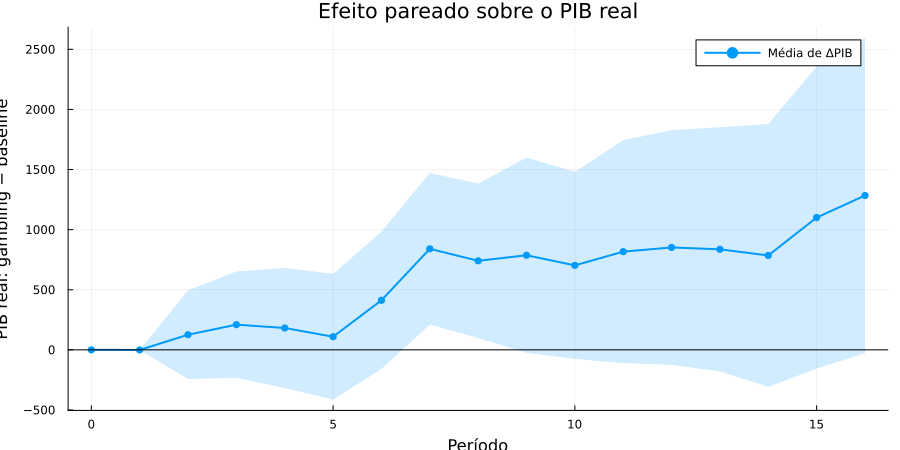

In [5]:
number_of_pairs = length(unique(paired.run))
t_critical = quantile(TDist(number_of_pairs - 1), 0.975)

gdp_by_period = combine(
    groupby(paired, :period),
    :delta_real_gdp => mean => :media,
    :delta_real_gdp => median => :mediana,
    :delta_real_gdp => std => :desvio_padrao,
    :delta_real_gdp => (x -> std(x) / sqrt(length(x))) => :erro_padrao,
    :delta_real_gdp => (x -> count(>(0), x)) => :pares_positivos,
)
transform!(gdp_by_period, [:media, :erro_padrao] => ByRow((m, se) -> m - t_critical * se) => :ic95_inferior)
transform!(gdp_by_period, [:media, :erro_padrao] => ByRow((m, se) -> m + t_critical * se) => :ic95_superior)

plot(
    gdp_by_period.period,
    gdp_by_period.media;
    ribbon = (
        gdp_by_period.media .- gdp_by_period.ic95_inferior,
        gdp_by_period.ic95_superior .- gdp_by_period.media,
    ),
    fillalpha = 0.18,
    marker = :circle,
    label = "Média de ΔPIB",
    xlabel = "Período",
    ylabel = "PIB real: gambling − baseline",
    title = "Efeito pareado sobre o PIB real",
)
hline!([0]; color = :black, linewidth = 1, label = false)

In [6]:
final_period = maximum(paired.period)
simulated_periods = filter(:period => >(0), paired)
mean_gdp_by_run = combine(
    groupby(simulated_periods, :run),
    :delta_real_gdp => mean => :delta_pib_medio,
)
final_gdp_by_run = select(
    filter(:period => ==(final_period), paired),
    :run, :delta_real_gdp => :delta_pib_final,
)
gdp_by_run = innerjoin(final_gdp_by_run, mean_gdp_by_run; on = :run)

gdp_summary = DataFrame(
    medida = String[], media = Float64[], mediana = Float64[],
    desvio_padrao = Float64[], ic95_inferior = Float64[],
    ic95_superior = Float64[], pares_positivos = Int[],
)
for (label, column) in [("PIB final", :delta_pib_final), ("PIB médio nos 16 períodos", :delta_pib_medio)]
    values = gdp_by_run[!, column]
    margin = t_critical * std(values) / sqrt(length(values))
    push!(gdp_summary, (
        label, mean(values), median(values), std(values),
        mean(values) - margin, mean(values) + margin, count(>(0), values),
    ))
end

gdp_summary

Row,medida,media,mediana,desvio_padrao,ic95_inferior,ic95_superior,pares_positivos
,String,Float64,Float64,Float64,Float64,Float64,Int64
1,PIB final,1283.77,992.485,2800.91,-27.0958,2594.64,14
2,PIB médio nos 16 períodos,611.426,630.544,1270.07,17.0138,1205.84,16


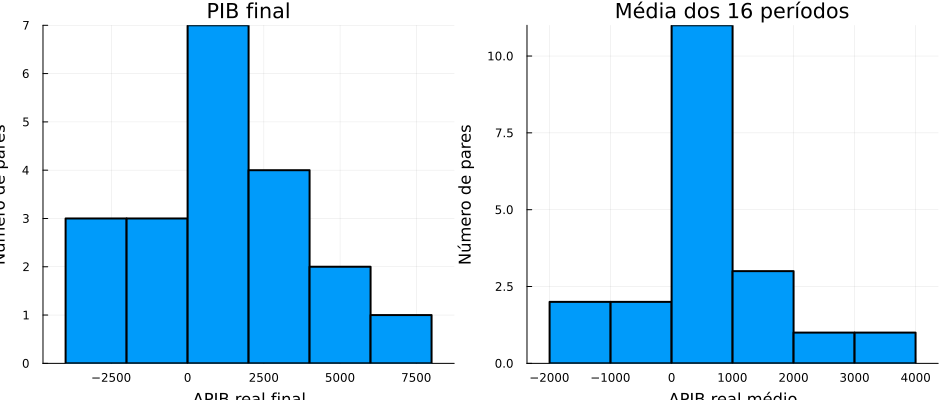

In [7]:
p_final = histogram(
    gdp_by_run.delta_pib_final; bins = 8, legend = false,
    xlabel = "ΔPIB real final", ylabel = "Número de pares", title = "PIB final",
)
vline!(p_final, [0]; color = :black, linewidth = 1)

p_mean = histogram(
    gdp_by_run.delta_pib_medio; bins = 8, legend = false,
    xlabel = "ΔPIB real médio", ylabel = "Número de pares", title = "Média dos 16 períodos",
)
vline!(p_mean, [0]; color = :black, linewidth = 1)

plot(p_final, p_mean; layout = (1, 2), size = (950, 400))

## 4. Decomposição contábil do PIB

A diferença do PIB deve ser reconciliada pela identidade:

$$
\Delta PIB = \Delta C + \Delta G + \Delta I + \Delta X - \Delta M.
$$

Essa decomposição identifica o componente contábil associado ao resultado; ela ainda não demonstra, sozinha, o mecanismo econômico.

┌ Warning: Keyword argument bar_position not supported with Plots.GRBackend().  Choose from: annotationcolor, annotationfontfamily, annotationfontsize, annotationhalign, annotationrotation, annotations, annotationvalign, arrow, aspect_ratio, axis, background_color, background_color_inside, background_color_outside, background_color_subplot, bar_width, bins, bottom_margin, camera, clims, color_palette, colorbar, colorbar_entry, colorbar_scale, colorbar_title, colorbar_titlefont, colorbar_titlefontcolor, colorbar_titlefontrotation, colorbar_titlefontsize, connections, contour_labels, discrete_values, fill, fill_z, fillalpha, fillcolor, fillrange, fillstyle, flip, fontfamily, fontfamily_subplot, foreground_color, foreground_color_axis, foreground_color_border, foreground_color_grid, foreground_color_subplot, foreground_color_text, formatter, framestyle, grid, gridalpha, gridlinewidth, gridstyle, group, guide, guidefont, guidefontcolor, guidefontfamily, guidefonthalign, guidefontrotation, 

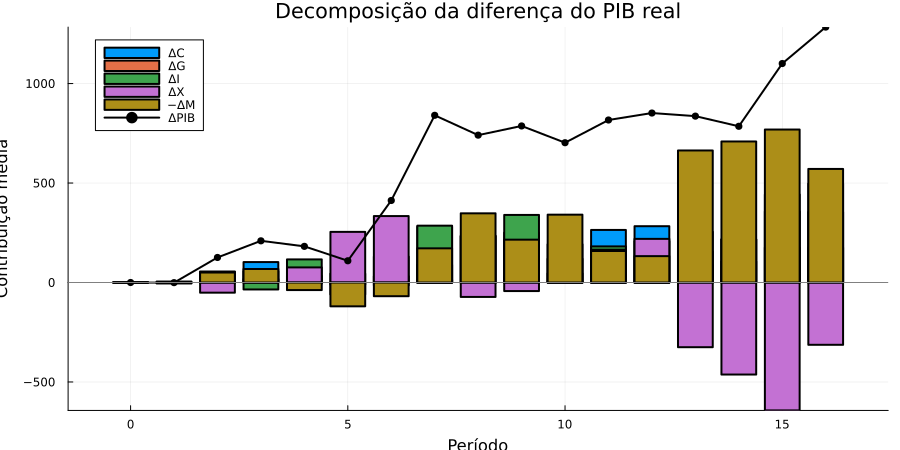

In [8]:
paired.delta_real_gdp_from_components =
    paired.delta_real_household_consumption .+
    paired.delta_real_government_consumption .+
    paired.delta_real_capitalformation .+
    paired.delta_real_exports .-
    paired.delta_real_imports
paired.delta_real_gdp_reconciliation_residual =
    paired.delta_real_gdp .- paired.delta_real_gdp_from_components

@assert maximum(abs.(paired.delta_real_gdp_reconciliation_residual)) < 1e-6

gdp_components_by_period = combine(
    groupby(paired, :period),
    :delta_real_household_consumption => mean => :delta_C,
    :delta_real_government_consumption => mean => :delta_G,
    :delta_real_capitalformation => mean => :delta_I,
    :delta_real_exports => mean => :delta_X,
    :delta_real_imports => (x -> -mean(x)) => :menos_delta_M,
    :delta_real_gdp => mean => :delta_PIB,
)

component_matrix = Matrix(select(
    gdp_components_by_period, :delta_C, :delta_G, :delta_I, :delta_X, :menos_delta_M,
))
bar(
    gdp_components_by_period.period, component_matrix;
    bar_position = :stack, label = ["ΔC" "ΔG" "ΔI" "ΔX" "−ΔM"],
    xlabel = "Período", ylabel = "Contribuição média",
    title = "Decomposição da diferença do PIB real",
)
plot!(
    gdp_components_by_period.period, gdp_components_by_period.delta_PIB;
    color = :black, marker = :circle, label = "ΔPIB",
)
hline!([0]; color = :gray, linewidth = 1, label = false)

In [9]:
component_horizon = DataFrame(
    componente = ["ΔC", "ΔG", "ΔI", "ΔX", "−ΔM"],
    contribuicao_media = [
        mean(simulated_periods.delta_real_household_consumption),
        mean(simulated_periods.delta_real_government_consumption),
        mean(simulated_periods.delta_real_capitalformation),
        mean(simulated_periods.delta_real_exports),
        -mean(simulated_periods.delta_real_imports),
    ],
)
component_horizon.magnitude = abs.(component_horizon.contribuicao_media)
sort!(component_horizon, :magnitude, rev = true)
select(component_horizon, Not(:magnitude))

Row,componente,contribuicao_media
,String,Float64
1,−ΔM,248.221
2,ΔC,195.784
3,ΔI,164.478
4,ΔG,42.4518
5,ΔX,-39.5087


## 5. Caminho da transferência

Primeiro verificamos o fluxo direto: quanto saiu dos trabalhadores ativos e inativos e quanto chegou aos proprietários. Em seguida comparamos a renda antes e depois da transferência, os depósitos e os gastos desejados e realizados.

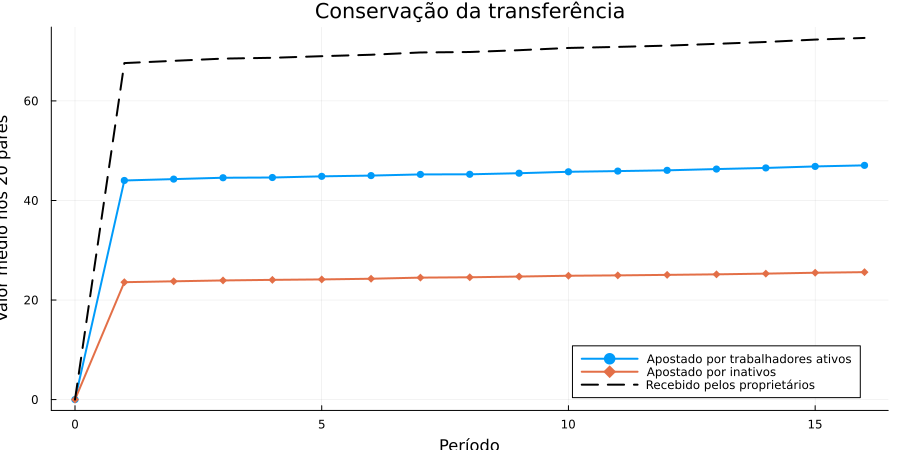

In [10]:
transfer_by_period = combine(
    groupby(gambling_trace, :period),
    :active_worker_stakes => mean => :trabalhadores_ativos,
    :inactive_worker_stakes => mean => :trabalhadores_inativos,
    :owner_receipts => mean => :proprietarios,
)
transfer_by_period.total_apostado =
    transfer_by_period.trabalhadores_ativos .+ transfer_by_period.trabalhadores_inativos

plot(
    transfer_by_period.period, transfer_by_period.trabalhadores_ativos;
    marker = :circle, label = "Apostado por trabalhadores ativos",
    xlabel = "Período", ylabel = "Valor médio nos 20 pares",
    title = "Conservação da transferência",
)
plot!(transfer_by_period.period, transfer_by_period.trabalhadores_inativos; marker = :diamond, label = "Apostado por inativos")
plot!(transfer_by_period.period, transfer_by_period.proprietarios; color = :black, linestyle = :dash, label = "Recebido pelos proprietários")

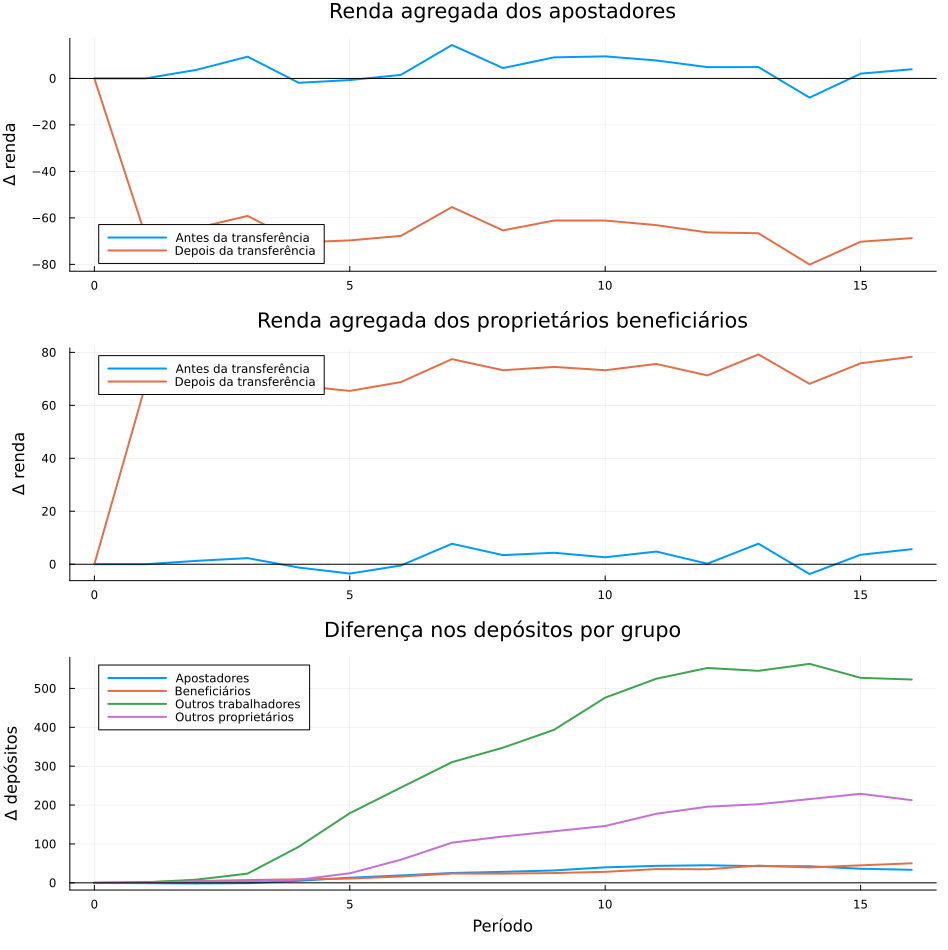

In [11]:
income_by_period = combine(
    groupby(paired, :period),
    :delta_gambler_income_pre => mean => :apostadores_antes,
    :delta_gambler_income_post => mean => :apostadores_depois,
    :delta_recipient_owner_income_pre => mean => :beneficiarios_antes,
    :delta_recipient_owner_income_post => mean => :beneficiarios_depois,
    :delta_gambler_deposits => mean => :depositos_apostadores,
    :delta_recipient_owner_deposits => mean => :depositos_beneficiarios,
    :delta_other_worker_deposits => mean => :depositos_outros_trabalhadores,
    :delta_other_owner_deposits => mean => :depositos_outros_proprietarios,
)

p_gambler_income = plot(
    income_by_period.period, income_by_period.apostadores_antes;
    label = "Antes da transferência", title = "Renda agregada dos apostadores", ylabel = "Δ renda",
)
plot!(p_gambler_income, income_by_period.period, income_by_period.apostadores_depois; label = "Depois da transferência")
hline!(p_gambler_income, [0]; color = :black, linewidth = 1, label = false)

p_owner_income = plot(
    income_by_period.period, income_by_period.beneficiarios_antes;
    label = "Antes da transferência", title = "Renda agregada dos proprietários beneficiários", ylabel = "Δ renda",
)
plot!(p_owner_income, income_by_period.period, income_by_period.beneficiarios_depois; label = "Depois da transferência")
hline!(p_owner_income, [0]; color = :black, linewidth = 1, label = false)

p_deposits = plot(
    income_by_period.period, income_by_period.depositos_apostadores;
    label = "Apostadores", title = "Diferença nos depósitos por grupo",
    xlabel = "Período", ylabel = "Δ depósitos",
)
plot!(p_deposits, income_by_period.period, income_by_period.depositos_beneficiarios; label = "Beneficiários")
plot!(p_deposits, income_by_period.period, income_by_period.depositos_outros_trabalhadores; label = "Outros trabalhadores")
plot!(p_deposits, income_by_period.period, income_by_period.depositos_outros_proprietarios; label = "Outros proprietários")
hline!(p_deposits, [0]; color = :black, linewidth = 1, label = false)

plot(p_gambler_income, p_owner_income, p_deposits; layout = (3, 1), size = (950, 950))

### Gastos desejados e realizados

Como os grupos possuem tamanhos muito diferentes, as comparações abaixo usam a diferença média por agente. Isso evita comparar diretamente centenas de apostadores com dezenas de proprietários beneficiários.

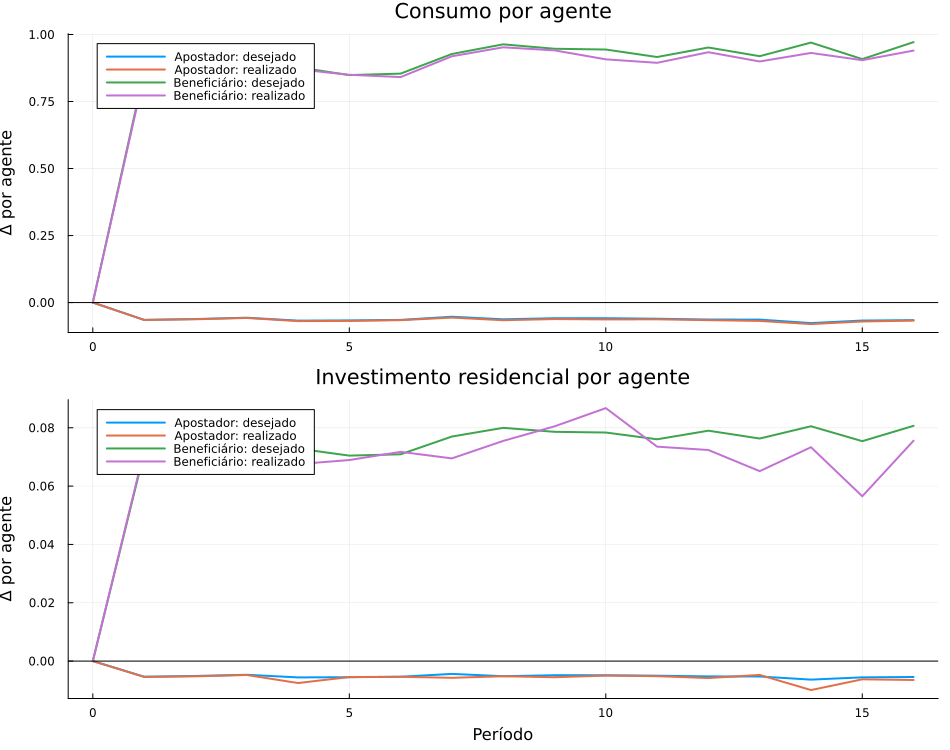

In [12]:
paired.delta_gambler_consumption_desired_per_agent = paired.delta_gambler_consumption_desired ./ paired.gamblers
paired.delta_gambler_consumption_realized_per_agent = paired.delta_gambler_consumption_realized ./ paired.gamblers
paired.delta_owner_consumption_desired_per_agent = paired.delta_recipient_owner_consumption_desired ./ paired.recipient_owners
paired.delta_owner_consumption_realized_per_agent = paired.delta_recipient_owner_consumption_realized ./ paired.recipient_owners
paired.delta_gambler_housing_desired_per_agent = paired.delta_gambler_housing_desired ./ paired.gamblers
paired.delta_gambler_housing_realized_per_agent = paired.delta_gambler_housing_realized ./ paired.gamblers
paired.delta_owner_housing_desired_per_agent = paired.delta_recipient_owner_housing_desired ./ paired.recipient_owners
paired.delta_owner_housing_realized_per_agent = paired.delta_recipient_owner_housing_realized ./ paired.recipient_owners

spending_by_period = combine(
    groupby(paired, :period),
    :delta_gambler_consumption_desired_per_agent => mean => :consumo_desejado_apostador,
    :delta_gambler_consumption_realized_per_agent => mean => :consumo_realizado_apostador,
    :delta_owner_consumption_desired_per_agent => mean => :consumo_desejado_beneficiario,
    :delta_owner_consumption_realized_per_agent => mean => :consumo_realizado_beneficiario,
    :delta_gambler_housing_desired_per_agent => mean => :habitacao_desejada_apostador,
    :delta_gambler_housing_realized_per_agent => mean => :habitacao_realizada_apostador,
    :delta_owner_housing_desired_per_agent => mean => :habitacao_desejada_beneficiario,
    :delta_owner_housing_realized_per_agent => mean => :habitacao_realizada_beneficiario,
)

p_consumption = plot(
    spending_by_period.period, spending_by_period.consumo_desejado_apostador;
    label = "Apostador: desejado", title = "Consumo por agente", ylabel = "Δ por agente",
)
plot!(p_consumption, spending_by_period.period, spending_by_period.consumo_realizado_apostador; label = "Apostador: realizado")
plot!(p_consumption, spending_by_period.period, spending_by_period.consumo_desejado_beneficiario; label = "Beneficiário: desejado")
plot!(p_consumption, spending_by_period.period, spending_by_period.consumo_realizado_beneficiario; label = "Beneficiário: realizado")
hline!(p_consumption, [0]; color = :black, linewidth = 1, label = false)

p_housing = plot(
    spending_by_period.period, spending_by_period.habitacao_desejada_apostador;
    label = "Apostador: desejado", title = "Investimento residencial por agente",
    xlabel = "Período", ylabel = "Δ por agente",
)
plot!(p_housing, spending_by_period.period, spending_by_period.habitacao_realizada_apostador; label = "Apostador: realizado")
plot!(p_housing, spending_by_period.period, spending_by_period.habitacao_desejada_beneficiario; label = "Beneficiário: desejado")
plot!(p_housing, spending_by_period.period, spending_by_period.habitacao_realizada_beneficiario; label = "Beneficiário: realizado")
hline!(p_housing, [0]; color = :black, linewidth = 1, label = false)

plot(p_consumption, p_housing; layout = (2, 1), size = (950, 750))

## 6. Propagação para as empresas

As trajetórias seguintes procuram a sequência `gasto realizado → vendas e lucros → produção e emprego`. Como a produção ocorre antes da transferência dentro do passo do modelo, também examinamos associações com o período seguinte.

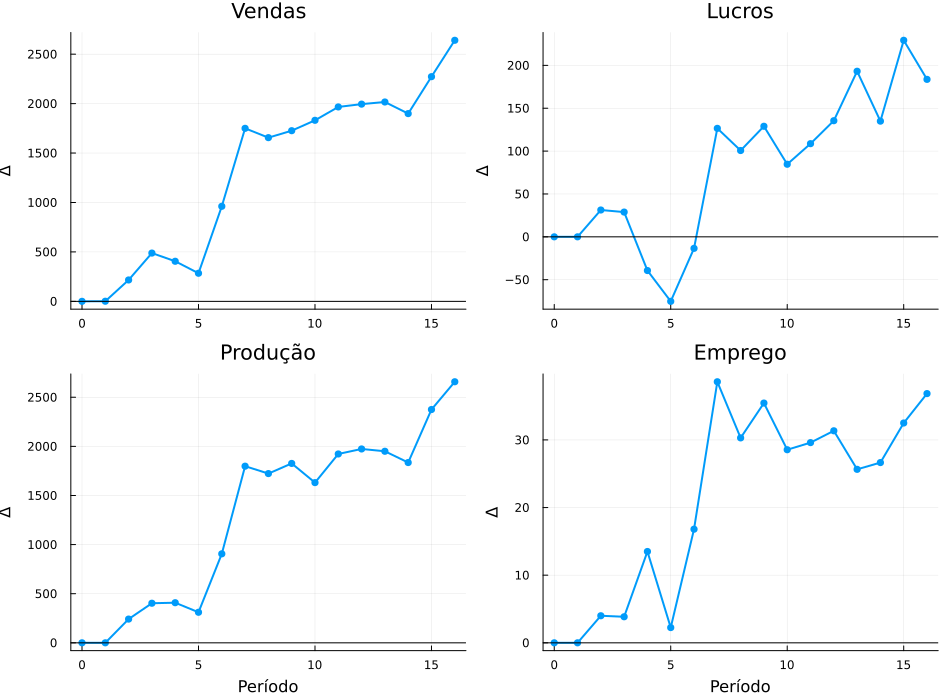

In [13]:
firm_by_period = combine(
    groupby(paired, :period),
    :delta_firm_sales => mean => :vendas,
    :delta_firm_profit => mean => :lucros,
    :delta_firm_output_realized => mean => :producao,
    :delta_firm_employment_realized => mean => :emprego,
    :delta_firm_investment_realized => mean => :investimento,
)

p_sales = plot(firm_by_period.period, firm_by_period.vendas; marker = :circle, label = false, title = "Vendas", ylabel = "Δ")
p_profit = plot(firm_by_period.period, firm_by_period.lucros; marker = :circle, label = false, title = "Lucros", ylabel = "Δ")
p_output = plot(firm_by_period.period, firm_by_period.producao; marker = :circle, label = false, title = "Produção", xlabel = "Período", ylabel = "Δ")
p_employment = plot(firm_by_period.period, firm_by_period.emprego; marker = :circle, label = false, title = "Emprego", xlabel = "Período", ylabel = "Δ")
for panel in (p_sales, p_profit, p_output, p_employment)
    hline!(panel, [0]; color = :black, linewidth = 1, label = false)
end
plot(p_sales, p_profit, p_output, p_employment; layout = (2, 2), size = (950, 700))

In [14]:
current_effects = select(
    filter(row -> 1 <= row.period < final_period, paired),
    :run, :period, :delta_household_consumption_realized, :delta_firm_sales,
)
next_effects = select(
    filter(row -> 2 <= row.period <= final_period, paired),
    :run,
    :period => ByRow(period -> period - 1) => :period,
    :delta_firm_output_realized => :delta_output_next,
    :delta_firm_employment_realized => :delta_employment_next,
    :delta_firm_investment_realized => :delta_investment_next,
)
lagged_effects = innerjoin(current_effects, next_effects; on = [:run, :period])

lagged_summary = DataFrame(
    relacao = [
        "Δ consumo realizado(t) × Δ vendas(t)",
        "Δ vendas(t) × Δ produção(t+1)",
        "Δ vendas(t) × Δ emprego(t+1)",
        "Δ vendas(t) × Δ investimento(t+1)",
    ],
    correlacao = [
        cor(lagged_effects.delta_household_consumption_realized, lagged_effects.delta_firm_sales),
        cor(lagged_effects.delta_firm_sales, lagged_effects.delta_output_next),
        cor(lagged_effects.delta_firm_sales, lagged_effects.delta_employment_next),
        cor(lagged_effects.delta_firm_sales, lagged_effects.delta_investment_next),
    ],
)
lagged_summary

Row,relacao,correlacao
,String,Float64
1,Δ consumo realizado(t) × Δ vendas(t),0.655219
2,Δ vendas(t) × Δ produção(t+1),0.928278
3,Δ vendas(t) × Δ emprego(t+1),0.800352
4,Δ vendas(t) × Δ investimento(t+1),0.821194


As correlações acima são descritivas. Elas ajudam a localizar uma sequência temporal compatível com o mecanismo, mas não devem ser interpretadas isoladamente como prova causal.

## 7. Execução ilustrativa mediana

Para ilustrar uma trajetória individual sem escolher retrospectivamente o caso mais favorável, selecionamos a execução cuja diferença média do PIB está mais próxima da mediana dos 20 pares.

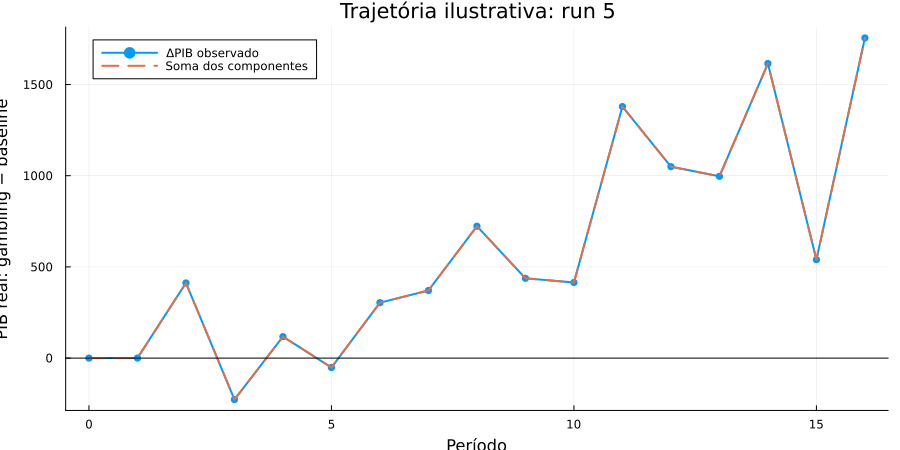

In [15]:
median_effect = median(gdp_by_run.delta_pib_medio)
median_run = gdp_by_run.run[argmin(abs.(gdp_by_run.delta_pib_medio .- median_effect))]
median_path = filter(:run => ==(median_run), paired)

plot(
    median_path.period, median_path.delta_real_gdp;
    marker = :circle, label = "ΔPIB observado",
    xlabel = "Período", ylabel = "PIB real: gambling − baseline",
    title = "Trajetória ilustrativa: run $median_run",
)
plot!(median_path.period, median_path.delta_real_gdp_from_components; linestyle = :dash, label = "Soma dos componentes")
hline!([0]; color = :black, linewidth = 1, label = false)

## 8. Conclusão provisória e limites

A célula seguinte resume automaticamente os principais números. A conclusão final deve distinguir três afirmações: a transferência foi conservada, o PIB apresentou uma diferença média e as variáveis intermediárias sustentam ou não um mecanismo econômico coerente.

In [16]:
final_result = gdp_summary[1, :]
average_result = gdp_summary[2, :]
dominant_component = component_horizon[1, :]
final_interval = final_result.ic95_inferior > 0 ?
    "inteiramente acima de zero" :
    final_result.ic95_superior < 0 ? "inteiramente abaixo de zero" : "inclui zero"
average_interval = average_result.ic95_inferior > 0 ?
    "inteiramente acima de zero" :
    average_result.ic95_superior < 0 ? "inteiramente abaixo de zero" : "inclui zero"

Markdown.parse("""
### Leitura dos resultados atuais

- A diferença média do **PIB real final** foi de **$(@sprintf("%.1f", final_result.media))**, positiva em **$(final_result.pares_positivos) de $number_of_pairs pares**. Seu intervalo de 95% **$final_interval**.
- A diferença do **PIB real médio ao longo dos 16 períodos** foi de **$(@sprintf("%.1f", average_result.media))**, positiva em **$(average_result.pares_positivos) de $number_of_pairs pares**. Seu intervalo de 95% **$average_interval**.
- O componente com maior contribuição média em valor absoluto foi **$(dominant_component.componente)**, com **$(@sprintf("%.1f", dominant_component.contribuicao_media))**.
- A conservação da transferência e a reconciliação contábil do PIB foram satisfeitas dentro das tolerâncias numéricas.

Esses resultados devem ser apresentados como evidência exploratória de 20 pares. Uma diferença positiva do PIB não basta para afirmar o mecanismo: a interpretação depende também da coerência entre renda, gastos realizados, resultados das empresas e defasagens temporais.
""")

### Leitura dos resultados atuais

  * A diferença média do **PIB real final** foi de **1283.8**, positiva em **14 de 20 pares**. Seu intervalo de 95% **inclui zero**.
  * A diferença do **PIB real médio ao longo dos 16 períodos** foi de **611.4**, positiva em **16 de 20 pares**. Seu intervalo de 95% **inteiramente acima de zero**.
  * O componente com maior contribuição média em valor absoluto foi **−ΔM**, com **248.2**.
  * A conservação da transferência e a reconciliação contábil do PIB foram satisfeitas dentro das tolerâncias numéricas.

Esses resultados devem ser apresentados como evidência exploratória de 20 pares. Uma diferença positiva do PIB não basta para afirmar o mecanismo: a interpretação depende também da coerência entre renda, gastos realizados, resultados das empresas e defasagens temporais.


### Limitações

1. O experimento possui apenas 20 pares e deve ser interpretado como exploratório.
2. O mecanismo representa uma transferência estilizada; não há produção de serviços de apostas, tributação específica ou operadores de apostas.
3. As correlações contemporâneas e defasadas descrevem associações dentro das simulações, não identificação causal adicional.
4. Se a conclusão depender de um efeito pequeno ou instável, o experimento deve ser repetido com mais sementes e, posteriormente, com outras parcelas de renda e taxas de participação.